<img src="https://full-stack-assets.s3.eu-west-3.amazonaws.com/M08-deep-learning/AT%26T_logo_2016.svg" alt="AT&T LOGO" width="50%" />

# AT&T Spam Detector -- Deep Learning Project

## Company Description

AT&T Inc. is an American multinational telecommunications holding company headquartered in Dallas, Texas. It is the world's largest telecommunications company by revenue.

## Objective

Build a spam detector that can automatically flag spam SMS messages based solely on their content. We will train and compare three approaches:

1. **Baseline M0** -- Traditional Machine Learning (Logistic Regression)
2. **Model A** -- Simple Neural Network (Embedding + Dense)
3. **Model C** -- Transfer Learning with Sentence-Transformers

We will evaluate and compare them using precision, recall, f1-score, and accuracy, then select the final recommendation based on observed test-set performance.

## 0. Install Dependencies

Run this cell once to ensure all required packages are installed.

In [1]:
!pip install -q tensorflow tf-keras wordcloud scikit-learn matplotlib seaborn sentence-transformers


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

## 1. Imports and Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Embedding,
    Dense,
    LSTM,
    Dropout,
    Bidirectional,
    GlobalAveragePooling1D,
    Input,
)
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow version: {tf.__version__}")


2026-05-06 17:07:08.857869: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-06 17:07:09.416389: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-05-06 17:07:11.319703: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.20.0


## 2. Data Loading and Exploration

We load `spam.csv`, keep only the relevant columns, and rename them.

The dataset contains 5,572 SMS messages labeled as **ham** (legitimate) or **spam**.

In [3]:
df = pd.read_csv("spam.csv", encoding="latin-1")

# Keep only relevant columns and rename them
df = df[["v1", "v2"]]
df.columns = ["label", "message"]

print(f"Dataset shape: {df.shape}")
df.head(10)


Dataset shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


### 2.1 Class Distribution

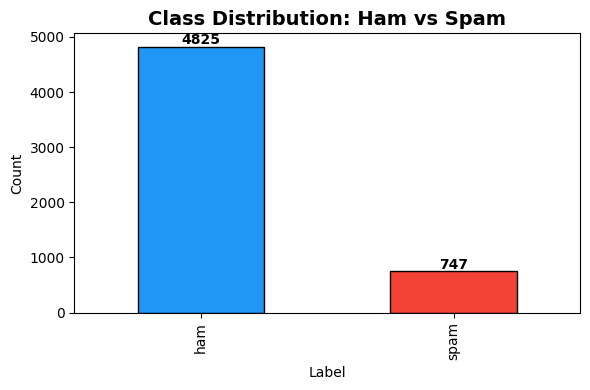


Ham: 4825 (86.6%)
Spam: 747 (13.4%)
Imbalance ratio: 6.5:1


In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df["label"].value_counts()
colors = ["#2196F3", "#F44336"]
counts.plot(kind="bar", color=colors, edgecolor="black", ax=ax)
ax.set_title("Class Distribution: Ham vs Spam", fontsize=14, fontweight="bold")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nHam: {counts['ham']} ({counts['ham']/len(df)*100:.1f}%)")
print(f"Spam: {counts['spam']} ({counts['spam']/len(df)*100:.1f}%)")
print(f"Imbalance ratio: {counts['ham']/counts['spam']:.1f}:1")


### 2.2 Message Length Analysis

Compare the distribution of message lengths between ham and spam.

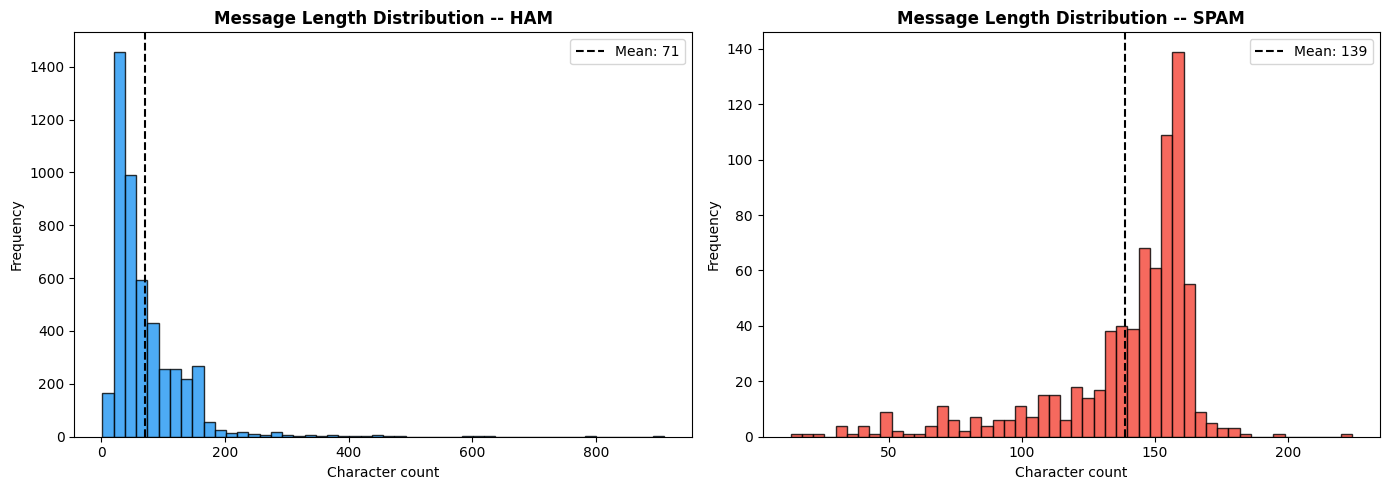

        count   mean   std   min    25%    50%    75%    max
label                                                       
ham    4825.0   71.0  58.0   2.0   33.0   52.0   92.0  910.0
spam    747.0  138.9  29.2  13.0  132.5  149.0  157.0  224.0


In [5]:
df["msg_length"] = df["message"].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, label in enumerate(["ham", "spam"]):
    subset = df[df["label"] == label]
    axes[i].hist(subset["msg_length"], bins=50, color=colors[i], edgecolor="black", alpha=0.8)
    axes[i].set_title(f"Message Length Distribution -- {label.upper()}", fontweight="bold")
    axes[i].set_xlabel("Character count")
    axes[i].set_ylabel("Frequency")
    axes[i].axvline(subset["msg_length"].mean(), color="black", linestyle="--",
                    label=f"Mean: {subset['msg_length'].mean():.0f}")
    axes[i].legend()

plt.tight_layout()
plt.show()

print(df.groupby("label")["msg_length"].describe().round(1))


### 2.3 Word Clouds

Visualize the most frequent words in spam vs. ham messages.

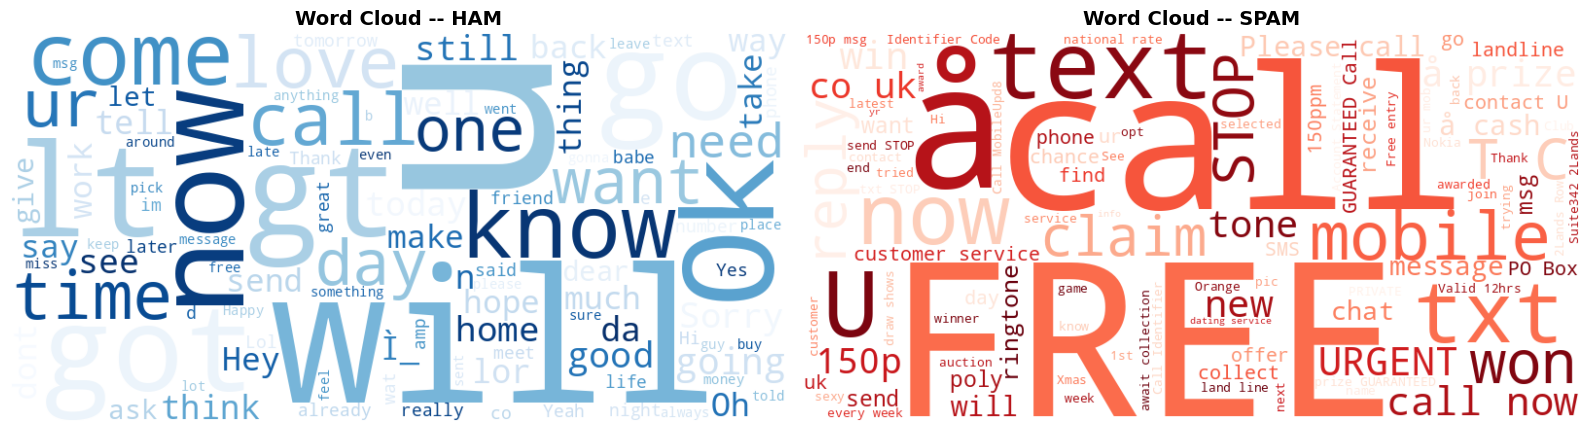

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, label in enumerate(["ham", "spam"]):
    text = " ".join(df[df["label"] == label]["message"].values)
    wc = WordCloud(
        width=800, height=400,
        background_color="white",
        colormap="Blues" if label == "ham" else "Reds",
        max_words=100,
    ).generate(text)
    axes[i].imshow(wc, interpolation="bilinear")
    axes[i].set_title(f"Word Cloud -- {label.upper()}", fontsize=14, fontweight="bold")
    axes[i].axis("off")

plt.tight_layout()
plt.show()


## 3. Text Preprocessing

Steps:
- **Clean text**: regex `str.replace(r"[\W_]+", " ")` removes punctuation but explicitly keeps alphanumeric characters (numbers are very important in SMS spam! e.g. shortcodes, phone numbers, prices).
- Encode labels (`ham=0`, `spam=1`)
- Train/test split (80/20, stratified to preserve the 13% spam distribution)
- **Tokenization**: convert text into integer sequences (each word = an integer).
- **Padding**: `pad_sequences` to make all inputs the same length (a requirement for Neural Networks).

In [7]:
# Encode labels
df["label_enc"] = df["label"].map({"ham": 0, "spam": 1})

# Clean text: remove special characters, underscores, and lowercase
df["clean_text"] = df["message"].str.replace(r"[\W_]+", " ", regex=True)
df["clean_text"] = df["clean_text"].fillna("").apply(lambda x: x.lower())

# Train/test split (stratified to preserve class balance)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["clean_text"], df["label_enc"],
    test_size=0.2,
    random_state=SEED,
    stratify=df["label_enc"],
)

print(f"Training set: {len(X_train_text)} samples")
print(f"Test set:     {len(X_test_text)} samples")
print(f"\nTraining class distribution:\n{y_train.value_counts().to_string()}")

# Tokenization
MAX_WORDS = 10000
MAX_LEN = 150

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

print(f"\nVocabulary size: {min(len(tokenizer.word_index)+1, MAX_WORDS)}")
print(f"Padded sequence shape: {X_train_pad.shape}")


Training set: 4457 samples
Test set:     1115 samples

Training class distribution:
label_enc
0    3859
1     598

Vocabulary size: 7739
Padded sequence shape: (4457, 150)


## 4. Baseline -- Traditional Machine Learning

Before using Deep Learning, let's establish a baseline using traditional machine learning (Logistic Regression) on TF-IDF vectorized text.

This will help us measure the actual added value of neural networks.

In [8]:
# TF-IDF Vectorization for classical ML
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=["ham", "spam"]))

results_lr = {"model": "Baseline (LogReg)", "accuracy": accuracy_score(y_test, y_pred_lr), "precision": precision_score(y_test, y_pred_lr), "recall": recall_score(y_test, y_pred_lr), "f1": f1_score(y_test, y_pred_lr), "y_pred": y_pred_lr}


=== Logistic Regression ===
              precision    recall  f1-score   support

         ham       0.97      1.00      0.99       966
        spam       0.99      0.82      0.90       149

    accuracy                           0.97      1115
   macro avg       0.98      0.91      0.94      1115
weighted avg       0.98      0.97      0.97      1115



## 5. Model A -- Simple Neural Network

Architecture: `Embedding` -> `GlobalAveragePooling1D` -> `Dense(24, relu)` -> `Dense(1, sigmoid)`

This is a deliberately simple baseline to assess how far we can go without recurrent layers.

In [9]:
model_a = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=32, input_length=MAX_LEN),
    GlobalAveragePooling1D(),
    Dense(24, activation="relu"),
    Dense(1, activation="sigmoid"),
])

model_a.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model_a.summary()


/home/phili/jedha_fullstack/PROJECTS_Deep_Learning_ATT_spam/venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2026-05-06 17:07:13.964205: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history_a = model_a.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1,
)


Epoch 1/15



  1/119 ━━━━━━━━━━━━━━━━━━━━ 2:10 1s/step - accuracy: 0.8125 - loss: 0.6854


 14/119 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8618 - loss: 0.5538 


 28/119 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8602 - loss: 0.5030


 45/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8591 - loss: 0.4756

...


 82/119 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9888 - loss: 0.0378


 94/119 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9887 - loss: 0.0381


106/119 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9887 - loss: 0.0382


118/119 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9887 - loss: 0.0382


119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9892 - loss: 0.0380 - val_accuracy: 0.9851 - val_loss: 0.0572


### Training Curves -- Model A

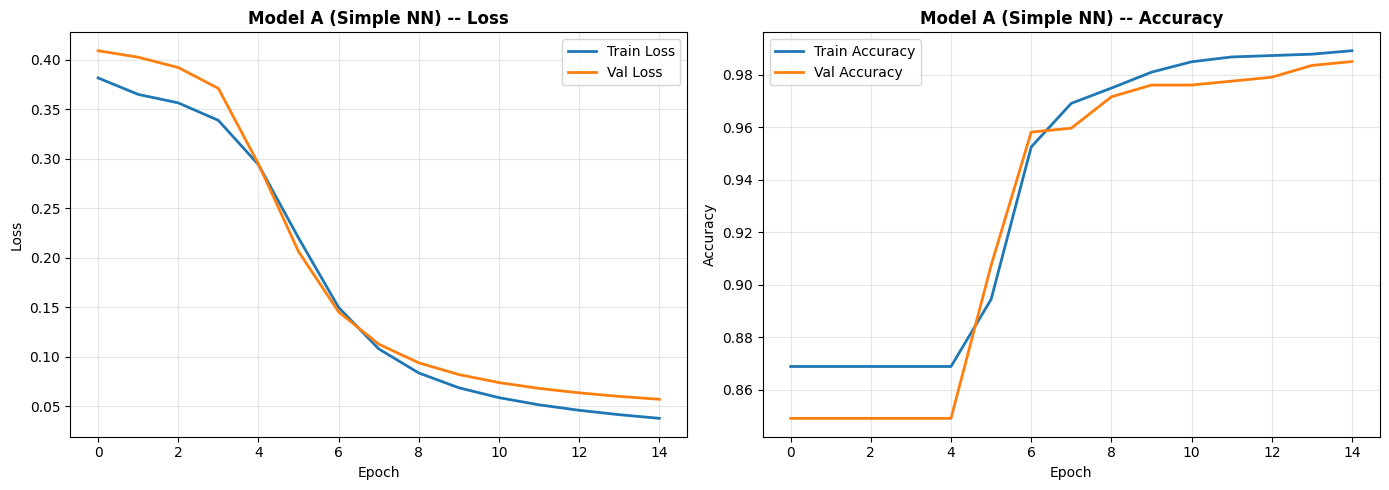

In [11]:
def plot_training_curves(history, model_name):
    """Plot loss and accuracy curves for a given training history."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    axes[0].plot(history.history["loss"], label="Train Loss", linewidth=2)
    axes[0].plot(history.history["val_loss"], label="Val Loss", linewidth=2)
    axes[0].set_title(f"{model_name} -- Loss", fontweight="bold")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(history.history["accuracy"], label="Train Accuracy", linewidth=2)
    axes[1].plot(history.history["val_accuracy"], label="Val Accuracy", linewidth=2)
    axes[1].set_title(f"{model_name} -- Accuracy", fontweight="bold")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_curves(history_a, "Model A (Simple NN)")


### Evaluation -- Model A

In [12]:
def evaluate_model(model, X_test, y_test, model_name, use_predict=True):
    """Evaluate a model and print the classification report."""
    if use_predict:
        y_pred_prob = model.predict(X_test)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
    else:
        y_pred = model  # already predictions

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"=== {model_name} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=["ham", "spam"]))

    return {"model": model_name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "y_pred": y_pred}

results_a = evaluate_model(model_a, X_test_pad, y_test, "Model A (Simple NN)")



 1/35 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step


15/35 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step


35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step 


=== Model A (Simple NN) ===
Accuracy:  0.9812
Precision: 0.9923
Recall:    0.8658
F1-Score:  0.9247

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.99      0.87      0.92       149

    accuracy                           0.98      1115
   macro avg       0.99      0.93      0.96      1115
weighted avg       0.98      0.98      0.98      1115



## 6. Model C -- Transfer Learning (Sentence-Transformers)

We use the **all-MiniLM-L6-v2** model from Sentence-Transformers to embed each message into a 384-dimensional vector. A simple dense classifier is trained on top.

This approach leverages a model pre-trained on a very large text corpus, which should provide rich semantic features even with limited data.

In [13]:
import os
os.environ["TRANSFORMERS_NO_TF"] = "1"

from sentence_transformers import SentenceTransformer

# Load the sentence-transformers model
print("Loading sentence-transformers model (all-MiniLM-L6-v2)...")
st_model = SentenceTransformer("all-MiniLM-L6-v2")

# Encode train and test messages into dense vectors (384 dimensions)
print("Encoding training messages...")
X_train_st = st_model.encode(X_train_text.tolist(), show_progress_bar=True, batch_size=64)

print("Encoding test messages...")
X_test_st = st_model.encode(X_test_text.tolist(), show_progress_bar=True, batch_size=64)

print(f"\nEmbedding shape: {X_train_st.shape}")


/home/phili/jedha_fullstack/PROJECTS_Deep_Learning_ATT_spam/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading sentence-transformers model (all-MiniLM-L6-v2)...



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Loading weights:   1%|          | 1/103 [00:00<00:00, 9686.61it/s, Materializing param=embeddings.LayerNorm.bias]


Loading weights:   1%|          | 1/103 [00:00<00:00, 580.21it/s, Materializing param=embeddings.LayerNorm.bias] 

...


Batches:  83%|████████▎ | 15/18 [00:04<00:00,  7.02it/s]


Batches:  89%|████████▉ | 16/18 [00:04<00:00,  7.71it/s]


Batches:  94%|█████████▍| 17/18 [00:06<00:00,  1.69it/s]


Batches: 100%|██████████| 18/18 [00:06<00:00,  2.86it/s]


Embedding shape: (4457, 384)


In [14]:
# Build a Dense classifier on top of the sentence embeddings
EMBED_DIM = X_train_st.shape[1]  # 384

model_c = Sequential([
    Input(shape=(EMBED_DIM,)),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid"),
])

model_c.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model_c.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,753 (104.50 KB)

 Trainable params: 26,753 (104.50 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
early_stop_c = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history_c = model_c.fit(
    X_train_st, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop_c],
    verbose=1,
)


Epoch 1/15



  1/119 ━━━━━━━━━━━━━━━━━━━━ 1:40 849ms/step - accuracy: 0.8438 - loss: 0.6643


 27/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8516 - loss: 0.5912    


 55/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8531 - loss: 0.5230


 83/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8556 - loss: 0.4709

...

Epoch 12/15



  1/119 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 1.0000 - loss: 0.0097


 42/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9993 - loss: 0.0040 


 83/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9994 - loss: 0.0038


119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9995 - loss: 0.0039 - val_accuracy: 0.9865 - val_loss: 0.0467


### Training Curves -- Model C

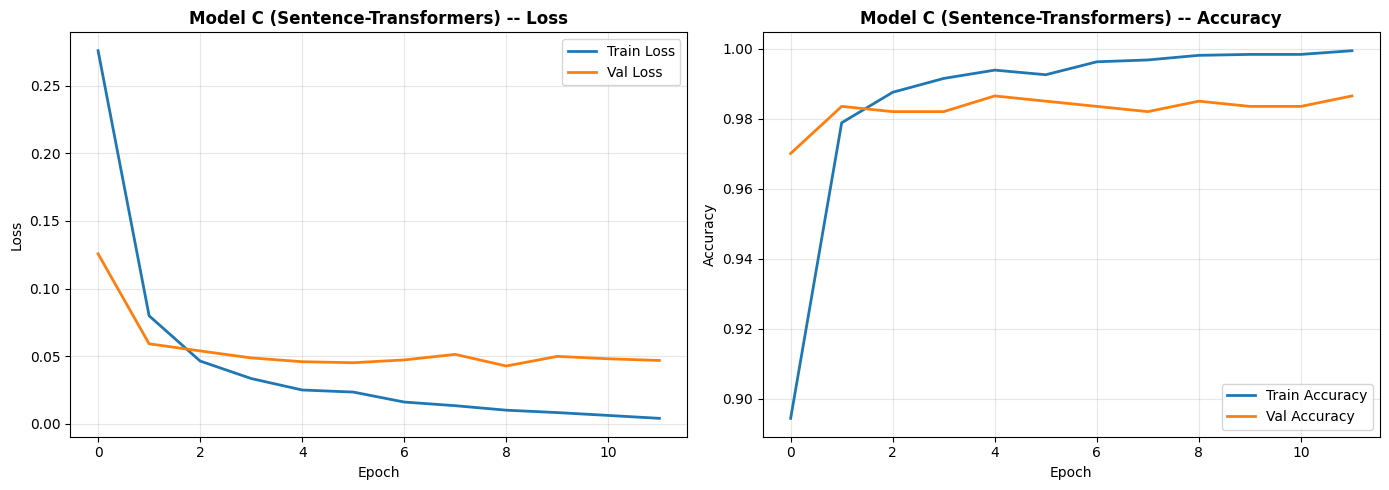

In [16]:
plot_training_curves(history_c, "Model C (Sentence-Transformers)")


### Evaluation -- Model C

In [17]:
results_c = evaluate_model(model_c, X_test_st, y_test, "Model C (Sentence-Transformers)")



 1/35 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


=== Model C (Sentence-Transformers) ===
Accuracy:  0.9839
Precision: 0.9580
Recall:    0.9195
F1-Score:  0.9384

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.96      0.92      0.94       149

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



## 7. Model Comparison

We compare all three models on the test set using accuracy, precision, recall, and F1-score.

In [18]:
# Build comparison table
comparison = pd.DataFrame([
    {k: v for k, v in results_lr.items() if k != "y_pred"},
    {k: v for k, v in results_a.items() if k != "y_pred"},
    {k: v for k, v in results_c.items() if k != "y_pred"},
])

comparison = comparison.set_index("model")

# Format as percentages
comparison_pct = comparison.apply(lambda x: x.map("{:.2%}".format))

print("=" * 60)
print("MODEL COMPARISON -- TEST SET PERFORMANCE")
print("=" * 60)
print(comparison_pct.to_string())
print()

# Highlight best model
best_model = comparison["f1"].idxmax()
print(f"Best model by F1-score: {best_model} ({comparison.loc[best_model, 'f1']:.2%})")


MODEL COMPARISON -- TEST SET PERFORMANCE
                                accuracy precision  recall      f1
model                                                             
Baseline (LogReg)                 97.49%    99.19%  81.88%  89.71%
Model A (Simple NN)               98.12%    99.23%  86.58%  92.47%
Model C (Sentence-Transformers)   98.39%    95.80%  91.95%  93.84%

Best model by F1-score: Model C (Sentence-Transformers) (93.84%)


### Confusion Matrices -- Side by Side

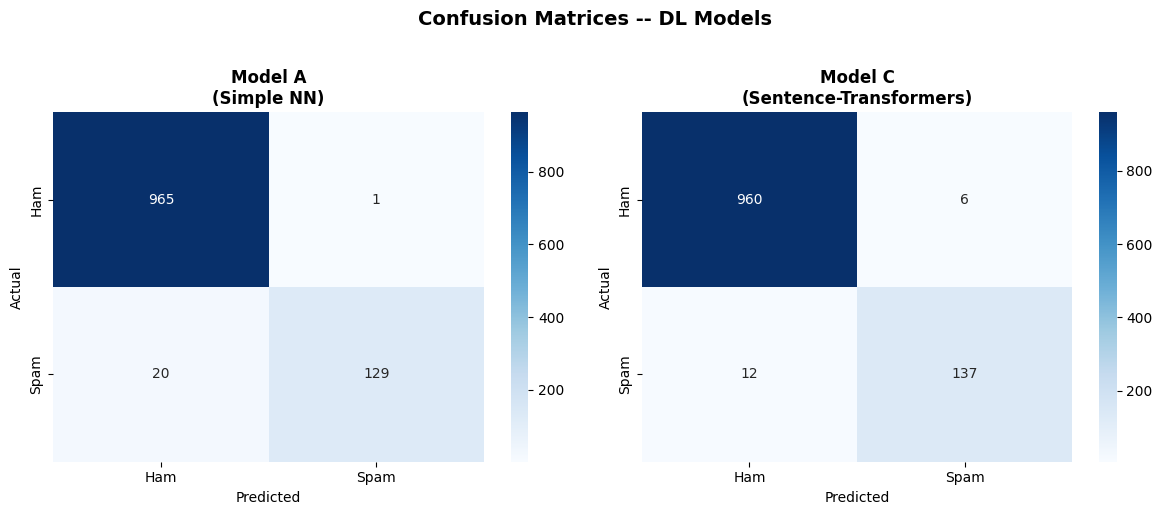

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

all_results = [results_a, results_c]
names = ["Model A\n(Simple NN)", "Model C\n(Sentence-Transformers)"]

for i, (res, name) in enumerate(zip(all_results, names)):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Ham", "Spam"],
        yticklabels=["Ham", "Spam"],
        ax=axes[i],
    )
    axes[i].set_title(f"{name}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.suptitle("Confusion Matrices -- DL Models", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 8. Conclusion & Qualitative Analysis

We trained and compared three approaches for SMS spam detection:

- **M0 (Logistic Regression)**: excellent baseline, but lower recall on the spam class.
- **Model A** (Simple NN): strong neural baseline with a high F1-score on the spam class.
- **Model C** (Sentence-Transformers Transfer Learning): best F1-score observed in this saved English run, around 94% on the spam class.

For this execution, **Model C (Sentence-Transformers)** is recommended. It provides the best observed trade-off between precision and recall on the spam class in this notebook.

Here are some concrete prediction examples of the selected model vs reality:

In [20]:
# Map predictions back to labels for the selected model (Model C)
best_preds = results_c["y_pred"]
mapping = {0: "ham", 1: "spam"}

results_df = pd.DataFrame({
    "message_text": X_test_text,
    "actual_label": y_test.map(mapping),
    "predicted_label": pd.Series(best_preds, index=y_test.index).map(mapping)
})

results_df["correct"] = results_df["actual_label"] == results_df["predicted_label"]

print("=== EXAMPLES OF CORRECT PREDICTIONS ===")
good_preds = results_df[results_df["correct"]].sample(5, random_state=SEED)
for i, row in good_preds.iterrows():
    print(f"\nTEXT: {row['message_text'][:100]}...")
    print(f"ACTUAL: {row['actual_label']}  |  PREDICTED: {row['predicted_label']}")

print("\n" + "="*50 + "\n")

print("=== EXAMPLES OF ERRORS (FALSE NEGATIVES / FALSE POSITIVES) ===")
errors = results_df[~results_df["correct"]]
if len(errors) > 0:
    error_sample = errors.head(5)
    for i, row in error_sample.iterrows():
        print(f"\nTEXT: {row['message_text'][:100]}...")
        print(f"ACTUAL: {row['actual_label']}  |  PREDICTED: {row['predicted_label']}  (INCORRECT)")
else:
    print("No errors found in this sample!")


=== EXAMPLES OF CORRECT PREDICTIONS ===

TEXT: send to someone else ...
ACTUAL: ham  |  PREDICTED: ham

TEXT: darren was saying dat if u meeting da ge den we dun meet 4 dinner cos later u leave xy will feel awk...
ACTUAL: ham  |  PREDICTED: ham

TEXT: sms auction a brand new nokia 7250 is up 4 auction today auction is free 2 join take part txt nokia ...
ACTUAL: spam  |  PREDICTED: spam

TEXT: from here after the performance award is calculated every two month not for current one month period...
ACTUAL: ham  |  PREDICTED: ham

TEXT: i don t know u and u don t know me send chat to 86688 now and let s find each other only 150p msg rc...
ACTUAL: spam  |  PREDICTED: spam


=== EXAMPLES OF ERRORS (FALSE NEGATIVES / FALSE POSITIVES) ===

TEXT: freemsg hey there darling it s been 3 week s now and no word back i d like some fun you up for it st...
ACTUAL: spam  |  PREDICTED: ham  (INCORRECT)

TEXT: ringtoneking 84484...
ACTUAL: spam  |  PREDICTED: ham  (INCORRECT)

TEXT: sorry i missed your cal